# POKEMON

### Analitika kitabxanalarının yüklənməsi və Datasetin Gətirilməsi

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [587]:
df = pd.read_excel(r"C:\Users\KN-90\OneDrive\Рабочий стол\Pokemon\Pokemon.xlsx")

In [588]:
df.rename(columns={'#': 'id'}, inplace=True)
df.head()

,id,name,type1,type2,base_total,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,is_legendary,generation,capture_rate,base_happiness,percentage_male
0,1,Bulbasaur,grass,poison,318,45,49,49,65,65,45,0.7,6.9,0,1,45,70,88.1
1,2,Ivysaur,grass,poison,405,60,62,63,80,80,60,1.0,13.0,0,1,45,70,88.1
2,3,Venusaur,grass,poison,625,80,100,123,122,120,80,2.0,100.0,0,1,45,70,88.1
3,4,Charmander,fire,NaN,309,39,52,43,60,50,65,0.6,8.5,0,1,45,70,88.1
4,5,Charmeleon,fire,NaN,405,58,64,58,80,65,80,1.1,19.0,0,1,45,70,88.1


#### Datasetdə ən çox yayılmış Pokemon növü hansıdır? Bu tip nə qədər Pokemon var?

In [434]:
df.groupby(['type1'])['type1'].count().sort_values(ascending = False).head()

type1
water      114
normal     105
grass       78
bug         72
psychic     53
Name: type1, dtype: int64

In [435]:
df.groupby(['type2'])['type2'].count().sort_values(ascending = False).head()

type2
flying     94
poison     34
ground     34
psychic    29
fairy      29
Name: type2, dtype: int64

In [436]:
df.groupby(['type1', 'type2' ])['id'].count().sort_values(ascending = False).head().reset_index()

,type1,type2,id
0,normal,flying,26
1,grass,poison,14
2,bug,flying,13
3,bug,poison,11
4,water,ground,9


#### Digər növləri ilə müqayisədə həddindən artıq yüksək və ya aşağı statistikaya malik hər hansı Pokemon varmı?

<Axes: ylabel='base_total'>

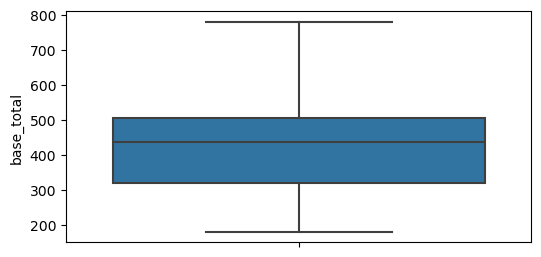

In [437]:
plt.figure(figsize = (6,3))
sns.boxplot(y = "base_total", data = df)

#### Pokemonun capture rate ilə onun base total arasında əlaqə varmı? Bəs onun nadirliyi (legendary və ya deyil)?

In [438]:
df['capture_rate'].corr(df['base_total'])

-0.7121201962428769

In [439]:
df['capture_rate'].corr(df['is_legendary'])

-0.3282121307256086

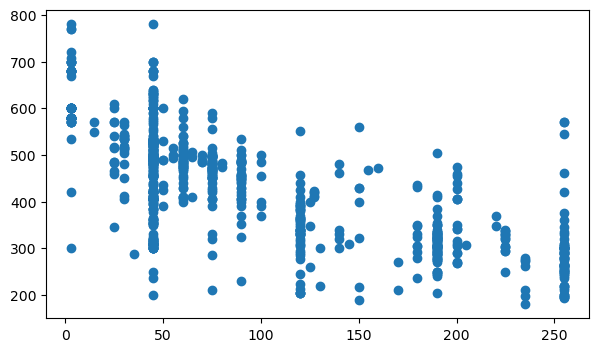

In [440]:
fig = plt.figure(figsize = (7,4))

plt.scatter(df['capture_rate'],df['base_total'])
plt.show()

#### Hansı Pokemon ən yüksək hücum statistikasına malikdir?

In [568]:
df['sum'] = df[['attack', 'sp_attack']].sum(axis=1)
df.groupby(['id','name'])['sum'].max().sort_values(ascending = False).head()


id   name    
384  Rayquaza    360
150  Mewtwo      344
382  Kyogre      330
383  Groudon     330
720  Hoopa       330
Name: sum, dtype: int64

#### Base total ilə HP, Attack, Defense, Special Attack, Special Defense və Speed kimi digər atributların hər biri arasında correlation nədir?

In [449]:
corr1=df['base_total'].corr(df['hp'])
print('corr1=',corr1)
corr2=df['base_total'].corr(df['attack'])
print('corr2=',corr2)
corr3=df['base_total'].corr(df['defense'])
print('corr3=',corr3)
corr4=df['base_total'].corr(df['sp_attack'])
print('corr4=',corr4)
corr5=df['base_total'].corr(df['sp_defense'])
print('corr5=',corr5)
corr6=df['base_total'].corr(df['speed'])
print('corr6=',corr6)

corr1= 0.6210619115159873
corr2= 0.7299978264684948
corr3= 0.6301512169063509
corr4= 0.7409856986308718
corr5= 0.7179583541478484
corr6= 0.5475754890793932


#### Əfsanəvi və əfsanəvi olmayan Pokemonun ortalama hücum  arasında əhəmiyyətli fərq varmı?

In [569]:
df['sum'] = df[['attack', 'sp_attack']].sum(axis=1)
df.groupby(['is_legendary'])['sum'].mean().sort_values(ascending = False).head().reset_index()

,is_legendary,sum
0,1,223.114286
1,0,142.002740


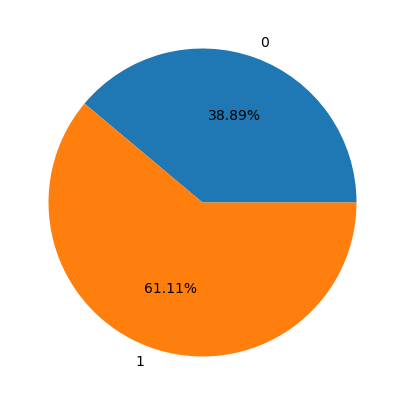

In [570]:
fig = plt.figure(figsize = (5,5))
plt.pie(df.groupby(['is_legendary'])['sum'].mean(), labels = df.groupby(['is_legendary'])['sum'].mean().index, autopct = "%1.2f%%")
plt.show()

#### Hansı tip 1 və tip 2 kombinasiyaları Pokemonlar arasında ən çox yayılmışdır?

In [221]:
df.groupby(['type1', 'type2' ])['id'].count().sort_values(ascending = False).head().reset_index()

,type1,type2,id
0,normal,flying,26
1,grass,poison,14
2,bug,flying,13
3,bug,poison,11
4,water,ground,9


#### Pokemonun çəkisi və boyu arasında korrelyasiya varmı?

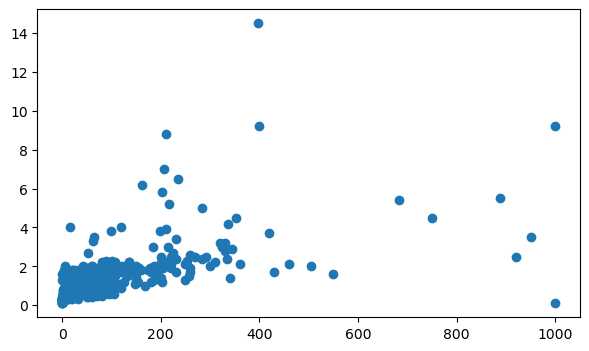

In [459]:
fig = plt.figure(figsize = (7,4))

plt.scatter(df['weight_kg'],df['height_m'])
plt.show()

In [213]:
df['weight_kg'].corr(df['height_m'])

0.6266230704400672

#### Hansı nəsil (generation) ən yüksək ortalama sürətə malikdir?

In [424]:
df.groupby(['generation'])['speed'].mean().sort_values(ascending = False)

generation
1    70.152318
4    70.074766
6    66.652778
5    66.519231
3    63.577778
7    63.329114
2    61.610000
Name: speed, dtype: float64

<Axes: xlabel='generation', ylabel='speed'>

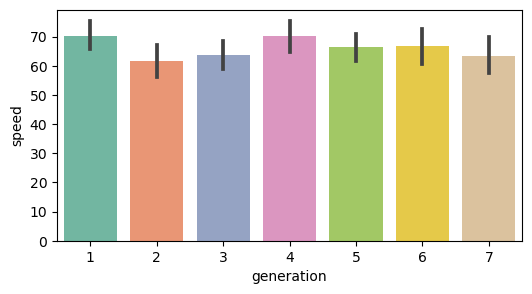

In [426]:
plt.figure(figsize = (6,3))
sns.barplot(x = 'generation', y = 'speed', data=df , palette = 'Set2')

#### Base total paylanması əfsanəvi və əfsanəvi olmayan Pokemon arasında necə dəyişir?

In [331]:
df = pd.DataFrame(df['base_total'], index = df['is_legendary'])

<Figure size 700x400 with 0 Axes>

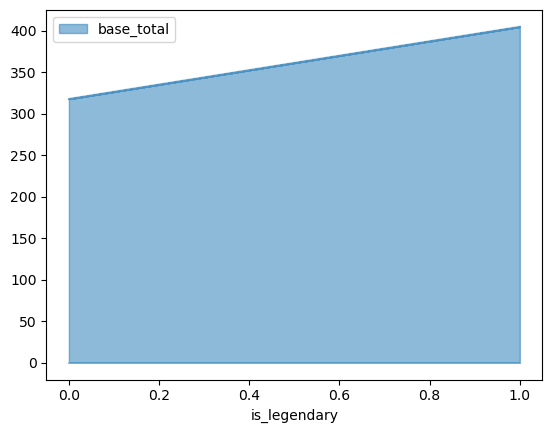

In [332]:
fig = plt.figure(figsize = (7,4))

df.plot(kind = "area", stacked = False)
plt.show()

#### Müxtəlif Pokemon tipləri arasında Defense paylanmasında əhəmiyyətli fərq varmı?

In [400]:
print(df.groupby(['type1'])['defense'].mean().sort_values(ascending = False).head().reset_index())
print(df.groupby(['type2'])['defense'].mean().sort_values(ascending = False).head().reset_index())

    type1     defense
0   steel  120.208333
1    rock   97.090909
2  dragon   86.259259
3  ground   83.906250
4   ghost   79.518519
     type2     defense
0     rock  131.142857
1    steel  106.272727
2    water   86.941176
3   ground   84.735294
4  psychic   84.310345


#### Pokemonun adını input kimi qəbul edən və onun statistikalarının olduğu lüğətini qaytaran funksiya yazın.

#### Percentage_male sütununda boş dəyərləri öz tipinin ortalaması ilə doldurun

In [591]:
df[['percentage_male']]=df[['percentage_male']].fillna(value = df['percentage_male'].mean())
df.head(200)

,id,name,type1,type2,base_total,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,is_legendary,generation,capture_rate,base_happiness,percentage_male
0,1,Bulbasaur,grass,poison,318,45,49,49,65,65,45,0.7,6.9,0,1,45,70,88.1
1,2,Ivysaur,grass,poison,405,60,62,63,80,80,60,1.0,13.0,0,1,45,70,88.1
2,3,Venusaur,grass,poison,625,80,100,123,122,120,80,2.0,100.0,0,1,45,70,88.1
3,4,Charmander,fire,NaN,309,39,52,43,60,50,65,0.6,8.5,0,1,45,70,88.1
4,5,Charmeleon,fire,NaN,405,58,64,58,80,65,80,1.1,19.0,0,1,45,70,88.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,Espeon,psychic,NaN,525,65,65,60,130,95,110,0.9,26.5,0,2,45,70,88.1
196,197,Umbreon,dark,NaN,525,95,65,110,60,130,65,1.0,27.0,0,2,45,35,88.1
197,198,Murkrow,dark,flying,405,60,85,42,85,42,91,0.5,2.1,0,2,30,35,50.0
198,199,Slowking,water,psychic,490,95,75,80,100,110,30,2.0,79.5,0,2,70,70,50.0


#### Daha çox kişiyə yaxın olan pokemonlar daha güclüdür, yoxsa qadına yaxın olanlar?

#### Əfsanəvi və ya əfsanəvi olmayan pokemonların ortalama çəkiləri və boyları arasında önəmli bir fərq var?

In [289]:
ortaceki=df.groupby(['is_legendary'])['weight_kg'].mean().sort_values(ascending = False).reset_index()
print(ortaceki)
ortaboy=df.groupby(['is_legendary'])['height_m'].mean().sort_values(ascending = False).reset_index()
print(ortaboy)

   is_legendary   weight_kg
0             1  199.350725
1             0   48.018425
   is_legendary  height_m
0             1  2.281159
1             0  1.056681


#### Hansı tip1 və tip2 kombinasiyası daha xoşbəxtdir?

In [180]:
df.groupby(['type1','type2'])['base_happiness'].max().sort_values(ascending = False).head().reset_index()

,type1,type2,base_happiness
0,psychic,fire,100
1,fire,water,100
2,fire,steel,100
3,psychic,ghost,100
4,psychic,grass,100


#### Tiplər üzrə ortalama çəki və boyları tapın

In [577]:
df_OrtaCeki=df.groupby(['type1'])['weight_kg'].mean().sort_values(ascending = False).head()
df_OrtaCeki

type1
steel     188.841667
ground    150.044444
dragon    107.125926
ice       103.260870
rock       94.270000
Name: weight_kg, dtype: float64

In [579]:
df_OrtaBoy=df.groupby(['type1'])['height_m'].mean().sort_values(ascending = False).head()
df_OrtaBoy

type1
dragon    1.937037
steel     1.875000
ground    1.340741
rock      1.330000
dark      1.296552
Name: height_m, dtype: float64

### Mən oynamaq üçün ən ideal pokemonu seçmək istəsəm, hansını seçməliyəm? Bunun üçün özünüzə uyğun xüsusi bir analiz aparın və seçdiyiniz pokemonu əsaslandırın

In [ ]:
Rayquaza,dragon (flying). Yuxarıda aparılan analizlərə görə ən güclü hücuma və special hücuma məxsus pokemondur. 
Həmçinin yüksək müdafiəyə və yaxşı sürətə sahibdir.

#### Apardığınız analizlərin nəticəsinə uyğun olaraq vizuallaşdırmalar aparın və bir dashboard qurun

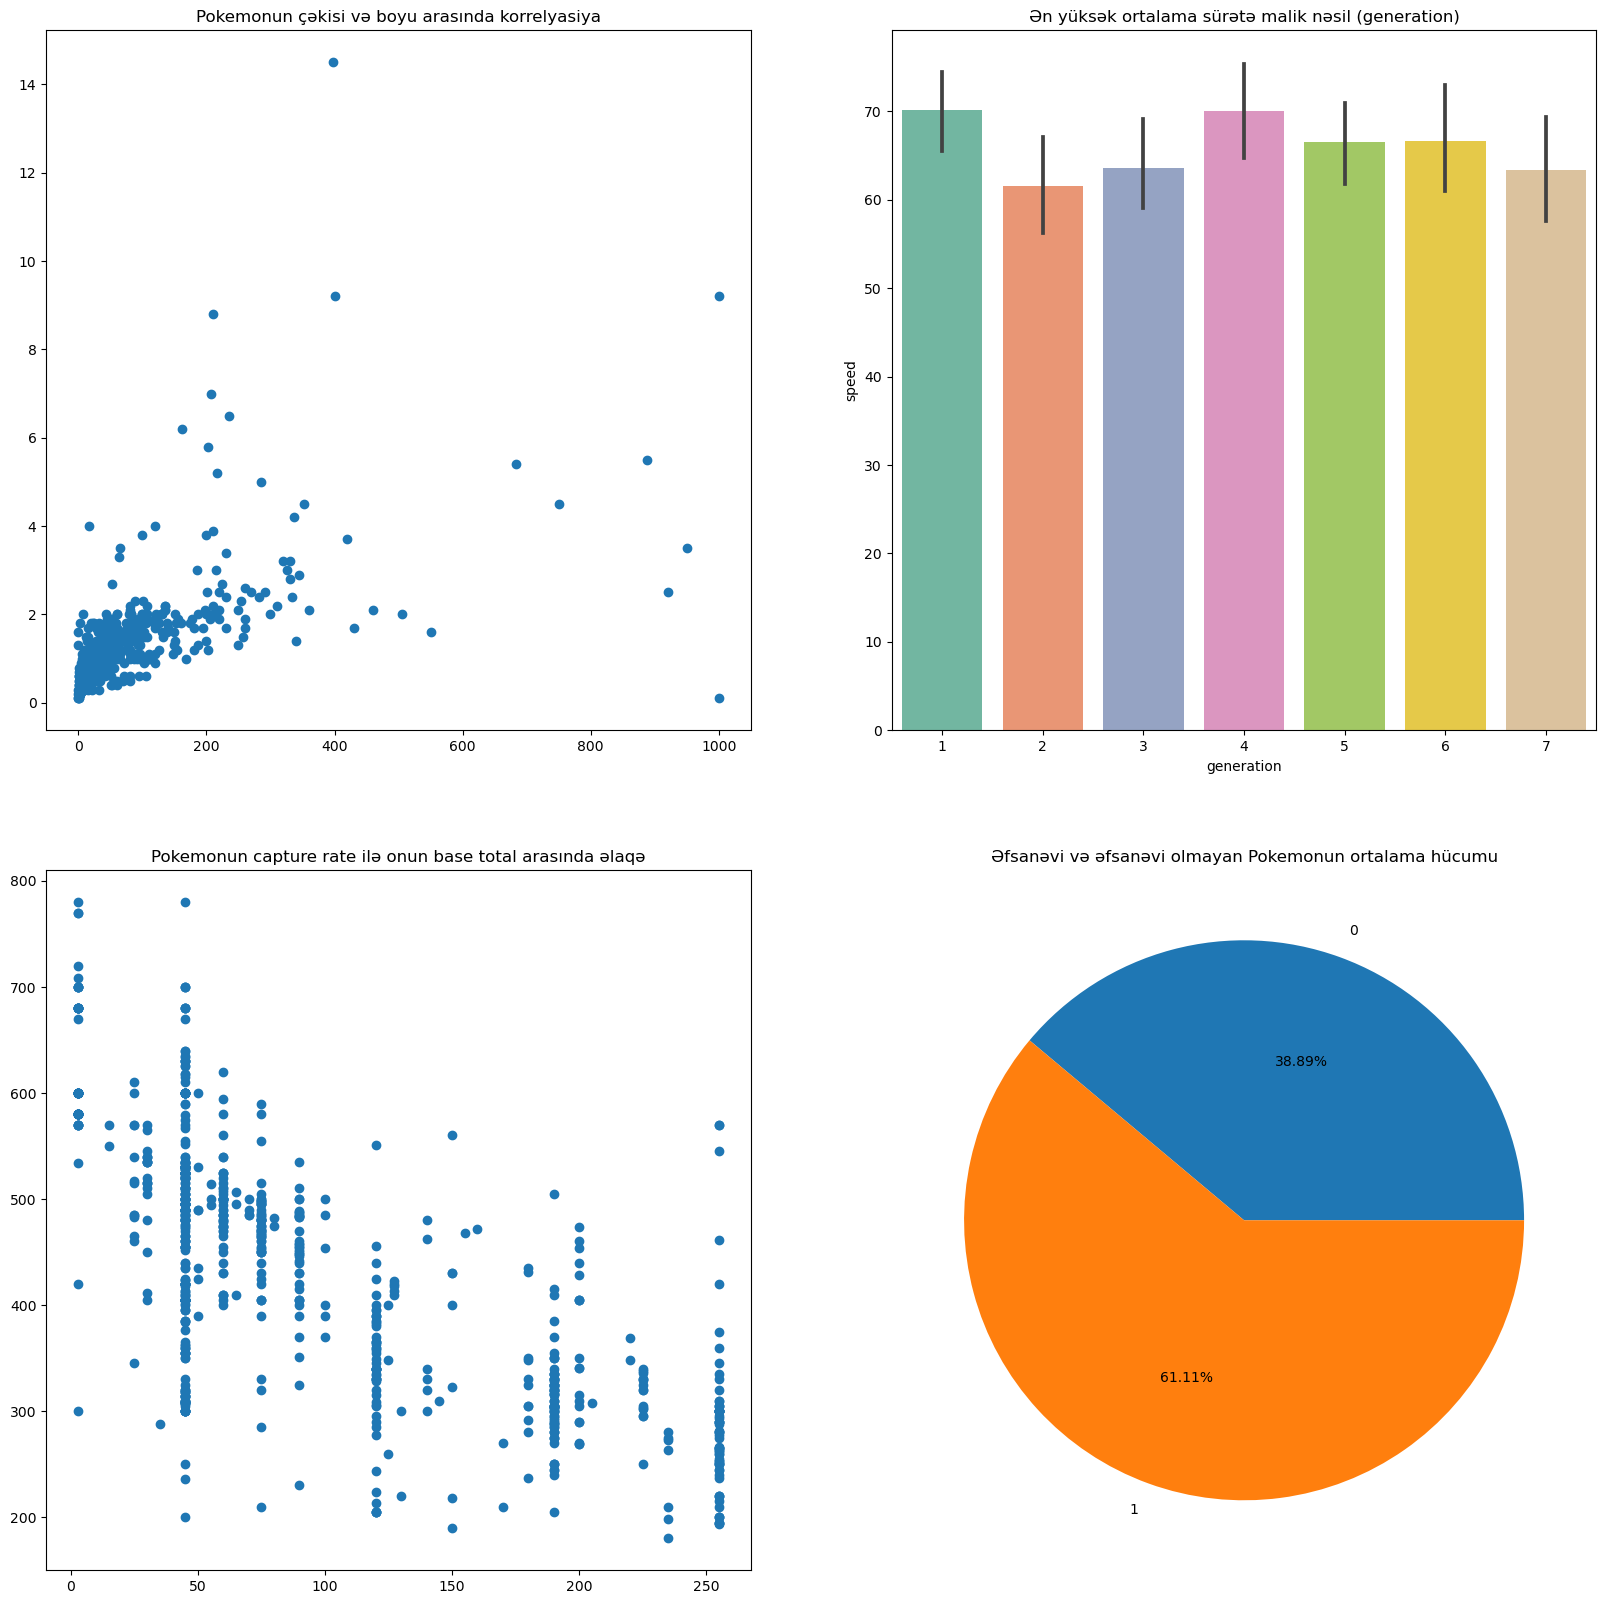

In [576]:
plt.figure(figsize = (20,20))

plt.subplot(2,2,1)

plt.scatter(df['weight_kg'],df['height_m'])
plt.title('Pokemonun çəkisi və boyu arasında korrelyasiya')

plt.subplot(2,2,2)

sns.barplot(x = 'generation', y = 'speed', data=df , palette = 'Set2')
plt.title('Ən yüksək ortalama sürətə malik nəsil (generation)')

plt.subplot(2,2,3)

plt.scatter(df['capture_rate'],df['base_total'])
plt.title('Pokemonun capture rate ilə onun base total arasında əlaqə')

plt.subplot(2,2,4)

df['sum'] = df[['attack', 'sp_attack']].sum(axis=1)
plt.pie(df.groupby(['is_legendary'])['sum'].mean(), labels = df.groupby(['is_legendary'])['sum'].mean().index, autopct = "%1.2f%%")
plt.title('Əfsanəvi və əfsanəvi olmayan Pokemonun ortalama hücumu')

plt.show()